<a href="https://colab.research.google.com/github/Lehuutien2908/DataMining/blob/main/research/training_models.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Dự đoán nguy cơ mắc bệnh tim

Notebook này trình bày toàn bộ quy trình xử lý dữ liệu, xây dựng và so sánh các mô hình (MLP, Random Forest, XGBoost, SVM) nhằm dự đoán khả năng mắc bệnh tim dựa trên các chỉ số lâm sàng.


## Quy trình tổng quát
- Khảo sát dữ liệu, kiểm tra thiếu và ngoại lệ
- Làm sạch, chuẩn hóa và chọn đặc trưng
- Chia dữ liệu train/test (stratify theo nhãn)
- Huấn luyện MLP (Keras Sequential) và các mô hình so sánh: Random Forest, XGBoost, SVM
- Đánh giá Accuracy, Precision, Recall, F1, Specificity, AUC-ROC


## Association Rules với Apriori Algorithm

Phân tích luật kết hợp để tìm các mẫu và mối quan hệ giữa các đặc trưng trong dữ liệu bệnh tim.


In [1]:
# Trong cell đầu tiên, chạy:
!pip install torch torchvision
!pip -q install pytorch-tabnet optuna

In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler

from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
import xgboost as xgb

from sklearn.metrics import (
    accuracy_score, recall_score, f1_score, confusion_matrix,
    roc_auc_score, roc_curve
)


import torch
import optuna
from pytorch_tabnet.tab_model import TabNetClassifier

import joblib

MODELS_DIR = Path("../backend/app/models")
MODELS_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42

DATA_PATH = Path("heart.csv")


   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   52    1   0       125   212    0        1      168      0      1.0      2   
1   53    1   0       140   203    1        0      155      1      3.1      0   
2   70    1   0       145   174    0        1      125      1      2.6      0   
3   61    1   0       148   203    0        1      161      0      0.0      2   
4   62    0   0       138   294    1        1      106      0      1.9      1   

   ca  thal  target  
0   2     3       0  
1   0     3       0  
2   0     3       0  
3   1     3       0  
4   3     2       0  
               age          sex           cp     trestbps        chol  \
count  1025.000000  1025.000000  1025.000000  1025.000000  1025.00000   
mean     54.434146     0.695610     0.942439   131.611707   246.00000   
std       9.072290     0.460373     1.029641    17.516718    51.59251   
min      29.000000     0.000000     0.000000    94.000000   126.00000   
25%      48.0000

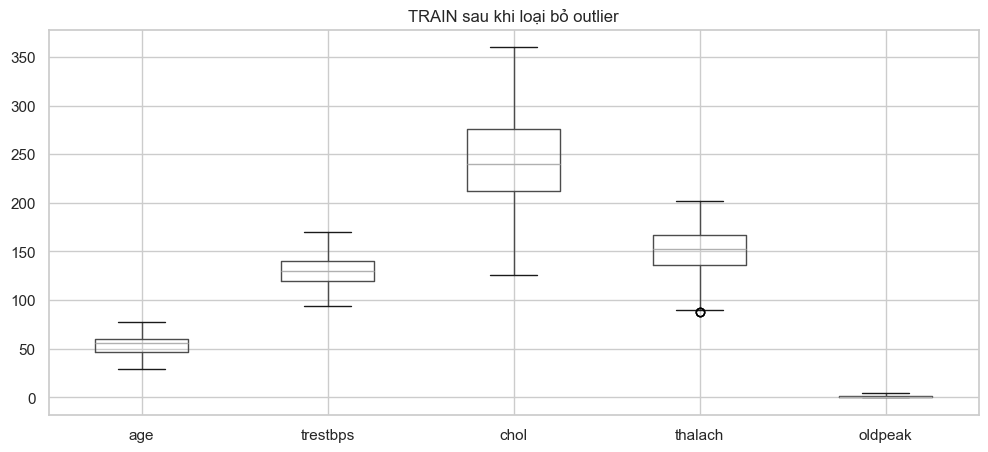

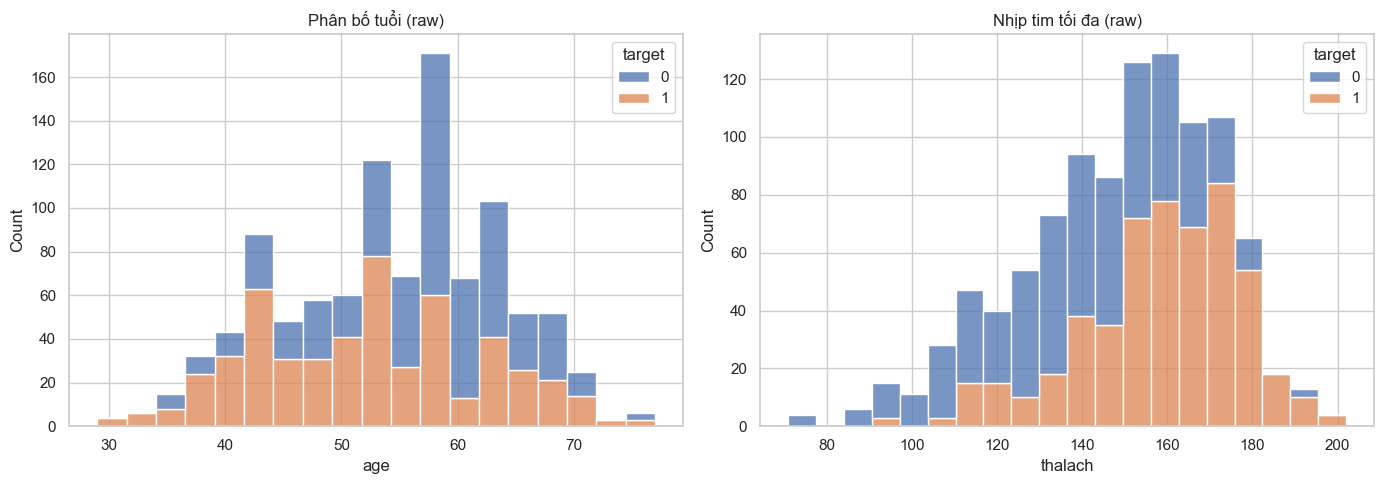

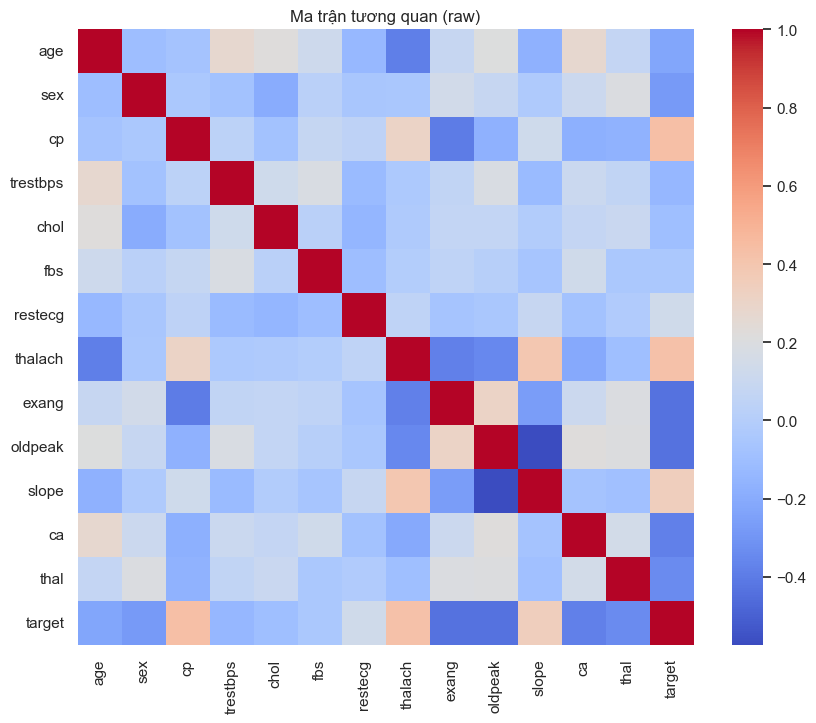

After outlier removal - X_train/X_test: (670, 13) (308, 13)


In [3]:
raw_df = pd.read_csv(DATA_PATH)

print(raw_df.head())
print(raw_df.describe())
print(raw_df.isna().sum())

if "target" not in raw_df.columns:
    raise ValueError("Không thấy cột 'target' trong heart.csv")

# ============================
# Train/Test split
# ============================
X = raw_df.drop(columns="target")
y = raw_df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=RANDOM_STATE,
    stratify=y
)

train_df = X_train.copy()
train_df["target"] = y_train.values

test_df = X_test.copy()
test_df["target"] = y_test.values


print("Before outlier removal - Train/Test:", train_df.shape, test_df.shape)

# ============================
# Outlier removal
# ============================
continuous_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

iqr_bounds = {}
old_train_rows = train_df.shape[0]

for col in continuous_cols:
    Q1 = train_df[col].quantile(0.25)
    Q3 = train_df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    iqr_bounds[col] = (float(lower_bound), float(upper_bound))

    outliers = ((train_df[col] < lower_bound) | (train_df[col] > upper_bound)).sum()
    if outliers > 0:
        print(f"'{col}': drop TRAIN={outliers} (bounds {lower_bound:.2f}, {upper_bound:.2f})")

    train_df = train_df[
        (train_df[col] >= lower_bound) &
        (train_df[col] <= upper_bound)
    ]

print(f"TRAIN removed: {old_train_rows - train_df.shape[0]} rows")
print("TRAIN shape after cleaning:", train_df.shape)
print("TEST shape:", test_df.shape)


plt.figure(figsize=(12, 5))
train_df[continuous_cols].boxplot()
plt.title("TRAIN sau khi loại bỏ outlier")
plt.show()


# ============================
# (Optional) EDA
# ============================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(data=raw_df, x="age", hue="target", multiple="stack", ax=axes[0])
sns.histplot(data=raw_df, x="thalach", hue="target", multiple="stack", ax=axes[1])
axes[0].set_title("Phân bố tuổi (raw)")
axes[1].set_title("Nhịp tim tối đa (raw)")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 8))
sns.heatmap(raw_df.corr(numeric_only=True), cmap="coolwarm", square=True)
plt.title("Ma trận tương quan (raw)")
plt.show()

# ============================
# Cập nhật lại X_train / X_test
# ============================
X_train = train_df.drop(columns="target")
y_train = train_df["target"]

X_test = test_df.drop(columns="target")
y_test = test_df["target"]


print("After outlier removal - X_train/X_test:", X_train.shape, X_test.shape)



In [4]:
import time
from sklearn.base import clone

def cv_auc_and_time(model, X_df, y_sr, features, cv_splits=5, seed=42):
    skf = StratifiedKFold(n_splits=cv_splits, shuffle=True, random_state=seed)
    aucs, fit_times = [], []

    for tr_idx, va_idx in skf.split(X_df, y_sr):
        X_tr = X_df.iloc[tr_idx][features]
        X_va = X_df.iloc[va_idx][features]
        y_tr = y_sr.iloc[tr_idx]
        y_va = y_sr.iloc[va_idx]

        m = clone(model)
        t0 = time.perf_counter()
        m.fit(X_tr, y_tr)
        fit_times.append(time.perf_counter() - t0)

        proba = m.predict_proba(X_va)[:, 1]
        aucs.append(roc_auc_score(y_va, proba))

    return float(np.mean(aucs)), float(np.std(aucs)), float(np.mean(fit_times))


def sweep_topk(model, X_df, y_sr, ranked_features, k_min=1, k_max=None, cv_splits=5, seed=42):
    if k_max is None:
        k_max = len(ranked_features)

    rows = []
    for k in range(k_min, k_max + 1):
        feats = ranked_features[:k]
        mean_auc, std_auc, mean_fit_time = cv_auc_and_time(
            model, X_df, y_sr, feats, cv_splits=cv_splits, seed=seed
        )
        rows.append({
            "k": k,
            "mean_auc": mean_auc,
            "std_auc": std_auc,
            "mean_fit_time_sec": mean_fit_time,
            "features": feats
        })

    res = pd.DataFrame(rows).sort_values("k").reset_index(drop=True)

    best_row = res.loc[res["mean_auc"].idxmax()]
    threshold = best_row["mean_auc"] - best_row["std_auc"]
    chosen = res[res["mean_auc"] >= threshold].iloc[0]

    return res, best_row, chosen


# ---- RF ranking (train only) ----
rf_rank = RandomForestClassifier(
    n_estimators=500,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    class_weight="balanced"
)
rf_rank.fit(X_train, y_train)

gini_importances = pd.Series(rf_rank.feature_importances_, index=X_train.columns).sort_values(ascending=False)
ranked_features = gini_importances.index.tolist()

print("\n=== GINI IMPORTANCE (RF trained on TRAIN) ===")
print(gini_importances)

# ---- Sweep top-k (train only) ----
rf_for_sweep = RandomForestClassifier(
    n_estimators=500,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    class_weight="balanced"
)

rf_table, rf_best, rf_chosen = sweep_topk(
    rf_for_sweep, X_train, y_train, ranked_features,
    k_min=1, k_max=len(ranked_features),
    cv_splits=5, seed=RANDOM_STATE
)

selected_features = rf_chosen["features"]

print("\n=== RF sweep top-k (CV on TRAIN) ===")
print(rf_table[["k", "mean_auc", "std_auc", "mean_fit_time_sec"]])
print("\nBest RF row:", dict(rf_best[["k","mean_auc","std_auc","mean_fit_time_sec"]]))
print("Chosen (smallest within 1σ best):", dict(rf_chosen[["k","mean_auc","std_auc","mean_fit_time_sec"]]))
print("\nSELECTED FEATURES:", selected_features)



=== GINI IMPORTANCE (RF trained on TRAIN) ===
cp          0.144550
ca          0.122160
thalach     0.114005
age         0.104865
thal        0.104490
oldpeak     0.102206
chol        0.081418
trestbps    0.068547
exang       0.057777
slope       0.035433
sex         0.035119
restecg     0.018663
fbs         0.010769
dtype: float64

=== RF sweep top-k (CV on TRAIN) ===
     k  mean_auc   std_auc  mean_fit_time_sec
0    1  0.779543  0.024126           1.494907
1    2  0.855858  0.035861           1.637024
2    3  0.961344  0.009974           1.564756
3    4  0.979896  0.011653           1.445508
4    5  0.986928  0.007603           1.686838
5    6  0.994047  0.004849           1.825092
6    7  0.994806  0.005019           1.724475
7    8  0.994918  0.005349           1.890501
8    9  0.995434  0.003990           1.552599
9   10  0.995120  0.005069           1.090532
10  11  0.996037  0.004644           1.207553
11  12  0.996216  0.004865           0.896643
12  13  0.996172  0.004878   

In [5]:
scaler = StandardScaler()
X_train_selected = scaler.fit_transform(X_train[selected_features])
X_test_selected  = scaler.transform(X_test[selected_features])

def evaluate_model(name, y_true, y_prob, threshold=0.5):
    y_pred = (y_prob >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    npv = tn / (tn + fn) if (tn + fn) > 0 else 0
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
    fnr = fn / (fn + tp) if (fn + tp) > 0 else 0
    balanced_accuracy = (sensitivity + specificity) / 2

    return {
        "model": name,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision,
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "specificity": specificity,
        "sensitivity": sensitivity,
        "npv": npv,
        "fpr": fpr,
        "fnr": fnr,
        "balanced_accuracy": balanced_accuracy,
        "auc": roc_auc_score(y_true, y_prob),
    }

results = []
roc_curves = {}


In [6]:
svm_params = {
    "C": [0.1, 1, 10, 100],
    "gamma": ["scale", "auto", 0.001, 0.01, 0.1, 1],
}

svm_grid = GridSearchCV(
    SVC(kernel="rbf", probability=True, random_state=RANDOM_STATE),
    svm_params,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1
)

svm_grid.fit(X_train_selected, y_train)
svm_model = svm_grid.best_estimator_
print("SVM best params:", svm_grid.best_params_)

svm_probs = svm_model.predict_proba(X_test_selected)[:, 1]
results.append(evaluate_model("SVM (RBF)", y_test.values, svm_probs))
roc_curves["SVM (RBF)"] = roc_curve(y_test, svm_probs)


SVM best params: {'C': 100, 'gamma': 1}


In [7]:
xgb_params = {
    "n_estimators": [100, 200],
    "max_depth": [3, 5],
    "learning_rate": [0.03, 0.05, 0.1],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0],
}

xgb_grid = GridSearchCV(
    xgb.XGBClassifier(
        eval_metric="logloss",
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),
    param_grid=xgb_params,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1
)

xgb_grid.fit(X_train_selected, y_train)
xgb_model = xgb_grid.best_estimator_
print("XGBoost best params:", xgb_grid.best_params_)

xgb_probs = xgb_model.predict_proba(X_test_selected)[:, 1]
results.append(evaluate_model("XGBoost", y_test.values, xgb_probs))
roc_curves["XGBoost"] = roc_curve(y_test, xgb_probs)


XGBoost best params: {'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 200, 'subsample': 0.8}


In [8]:
rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    class_weight="balanced"
)

rf_model.fit(X_train_selected, y_train)
rf_probs = rf_model.predict_proba(X_test_selected)[:, 1]

results.append(evaluate_model("Random Forest", y_test.values, rf_probs))
roc_curves["Random Forest"] = roc_curve(y_test, rf_probs)


In [9]:
import numpy as np
import torch
import optuna
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import roc_auc_score, roc_curve
from pytorch_tabnet.tab_model import TabNetClassifier

# TabNet needs float32
Xtr_all = X_train_selected.astype(np.float32)
ytr_all = y_train.values.astype(int)

Xte = X_test_selected.astype(np.float32)
yte = y_test.values.astype(int)

print("CUDA available:", torch.cuda.is_available())


def objective(trial: optuna.Trial) -> float:
    # --- Model capacity ---
    n_d = trial.suggest_categorical("n_d", [8, 16, 24, 32])
    n_a = trial.suggest_categorical("n_a", [8, 16, 24, 32])
    n_steps = trial.suggest_int("n_steps", 3, 6)
    gamma = trial.suggest_float("gamma", 1.0, 1.8)

    # --- Regularization / sparsity ---
    lambda_sparse = trial.suggest_float("lambda_sparse", 1e-6, 1e-3, log=True)
    mask_type = trial.suggest_categorical("mask_type", ["entmax", "sparsemax"])

    # --- Optimization ---
    lr = trial.suggest_float("lr", 1e-3, 3e-2, log=True)
    batch_size = trial.suggest_categorical("batch_size", [64, 128, 256])
    virtual_batch_size = trial.suggest_categorical("virtual_batch_size", [32, 64, 128])
    if virtual_batch_size > batch_size:
        virtual_batch_size = batch_size

    n_independent = trial.suggest_int("n_independent", 1, 2)
    n_shared = trial.suggest_int("n_shared", 1, 2)

    skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
    aucs = []

    for fold, (tr_idx, va_idx) in enumerate(skf.split(Xtr_all, ytr_all), start=1):
        Xtr, ytr = Xtr_all[tr_idx], ytr_all[tr_idx]
        Xva, yva = Xtr_all[va_idx], ytr_all[va_idx]

        tabnet = TabNetClassifier(
            n_d=n_d,
            n_a=n_a,
            n_steps=n_steps,
            gamma=gamma,
            n_independent=n_independent,
            n_shared=n_shared,
            lambda_sparse=lambda_sparse,
            mask_type=mask_type,
            optimizer_fn=torch.optim.Adam,
            optimizer_params=dict(lr=lr),
            seed=RANDOM_STATE,
            verbose=0
        )

        tabnet.fit(
            Xtr, ytr,
            eval_set=[(Xva, yva)],
            eval_metric=["auc"],
            max_epochs=200,
            patience=30,               # early stop theo fold-val
            batch_size=batch_size,
            virtual_batch_size=virtual_batch_size,
            num_workers=0,
            drop_last=False
        )

        p = tabnet.predict_proba(Xva)[:, 1]
        fold_auc = roc_auc_score(yva, p)
        aucs.append(fold_auc)

        trial.report(float(np.mean(aucs)), step=fold)
        if trial.should_prune():
            raise optuna.TrialPruned()

    return float(np.mean(aucs))


sampler = optuna.samplers.TPESampler(seed=RANDOM_STATE)
pruner = optuna.pruners.MedianPruner(n_warmup_steps=2)  
study = optuna.create_study(direction="maximize", sampler=sampler, pruner=pruner)

study.optimize(objective, n_trials=30, show_progress_bar=True)

print("Best CV AUC:", study.best_value)
print("Best params:", study.best_params)


best = study.best_params

# split train -> train_final / val_final (chỉ dùng trong training loop)
Xtr_f, Xva_f, ytr_f, yva_f = train_test_split(
    Xtr_all, ytr_all,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=ytr_all
)

tabnet_best = TabNetClassifier(
    n_d=best["n_d"],
    n_a=best["n_a"],
    n_steps=best["n_steps"],
    gamma=best["gamma"],
    n_independent=best["n_independent"],
    n_shared=best["n_shared"],
    lambda_sparse=best["lambda_sparse"],
    mask_type=best["mask_type"],
    optimizer_fn=torch.optim.Adam,
    optimizer_params=dict(lr=best["lr"]),
    seed=RANDOM_STATE,
    verbose=10
)

batch_size = best["batch_size"]
virtual_batch_size = best["virtual_batch_size"]
if virtual_batch_size > batch_size:
    virtual_batch_size = batch_size

tabnet_best.fit(
    Xtr_f, ytr_f,
    eval_set=[(Xva_f, yva_f)],
    eval_metric=["auc"],
    max_epochs=400,
    patience=50,
    batch_size=batch_size,
    virtual_batch_size=virtual_batch_size,
    num_workers=0,
    drop_last=False
)


tabnet_probs = tabnet_best.predict_proba(Xte)[:, 1]
results.append(evaluate_model("TabNet", yte, tabnet_probs))
roc_curves["TabNet (Optuna)"] = roc_curve(y_test, tabnet_probs)

tabnet_best.save_model(str(MODELS_DIR / "tabnet_optuna_2fold_10trial"))
print("Saved:", (MODELS_DIR / "tabnet_optuna_2fold_10trial.zip").resolve())


[I 2026-01-16 12:17:54,821] A new study created in memory with name: no-name-93a143d8-51e3-4ac1-8513-0f389bd90450


CUDA available: False


  0%|          | 0/30 [00:00<?, ?it/s]

Stop training because you reached max_epochs = 200 with best_epoch = 191 and best_val_0_auc = 0.95409

Early stopping occurred at epoch 102 with best_epoch = 72 and best_val_0_auc = 0.9714


Best trial: 0. Best value: 0.964495:   3%|▎         | 1/30 [02:35<1:15:11, 155.58s/it]

...

Best trial: 27. Best value: 0.987805:  97%|█████████▋| 29/30 [24:07<00:41, 41.89s/it]


Early stopping occurred at epoch 72 with best_epoch = 42 and best_val_0_auc = 0.96057
[I 2026-01-16 12:42:02,674] Trial 28 pruned. 

Early stopping occurred at epoch 69 with best_epoch = 39 and best_val_0_auc = 0.95873


Best trial: 27. Best value: 0.987805: 100%|██████████| 30/30 [24:46<00:00, 49.55s/it]


Early stopping occurred at epoch 64 with best_epoch = 34 and best_val_0_auc = 0.97624
[I 2026-01-16 12:42:41,323] Trial 29 pruned. 
Best CV AUC: 0.9878052503052502
Best params: {'n_d': 32, 'n_a': 32, 'n_steps': 3, 'gamma': 1.1668013916444235, 'lambda_sparse': 1.001529522897969e-05, 'mask_type': 'sparsemax', 'lr': 0.011335837012897523, 'batch_size': 64, 'virtual_batch_size': 128, 'n_independent': 1, 'n_shared': 1}


epoch 0  | loss: 0.57424 | val_0_auc: 0.81631 |  0:00:00s
epoch 10 | loss: 0.21845 | val_0_auc: 0.93851 |  0:00:01s
epoch 20 | loss: 0.20298 | val_0_auc: 0.93694 |  0:00:03s
epoch 30 | loss: 0.12983 | val_0_auc: 0.96147 |  0:00:05s
epoch 40 | loss: 0.17537 | val_0_auc: 0.94926 |  0:00:07s
epoch 50 | loss: 0.12835 | val_0_auc: 0.94926 |  0:00:09s
epoch 60 | loss: 0.18661 | val_0_auc: 0.94736 |  0:00:11s
epoch 70 | loss: 0.11111 | val_0_auc: 0.95273 |  0:00:13s
epoch 80 | loss: 0.0729  | val_0_auc: 0.95576 |  0:00:14s
epoch 90 | loss: 0.1091  | val_0_auc: 0.9487  |  0:00:16s
epoch 100| loss: 0.06764 | val_0_auc: 0.95004 |  0:00:18s
epoch 110| loss: 0.10316 | val_0_auc: 0.96707 |  0:00:20s
epoch 120| loss: 0.09809 | val_0_auc: 0.96326 |  0:00:22s

Early stopping occurred at epoch 125 with best_epoch = 75 and best_val_0_auc = 0.97323
Successfully saved model at ..\backend\app\models\tabnet_optuna_2fold_10trial.zip
Saved: E:\DataMinig\backend\app\models\tabnet_optuna_2fold_10trial.zip



=== RESULTS (sorted by AUC) ===
           model  accuracy  precision    recall        f1  specificity  \
0      SVM (RBF)  0.964286   1.000000  0.930380  0.963934     1.000000   
2  Random Forest  0.954545   0.973684  0.936709  0.954839     0.973333   
1        XGBoost  0.938312   0.954248  0.924051  0.938907     0.953333   
3         TabNet  0.909091   0.906250  0.917722  0.911950     0.900000   

   sensitivity       npv       fpr       fnr  balanced_accuracy       auc  
0     0.930380  0.931677  0.000000  0.069620           0.965190  0.997679  
2     0.936709  0.935897  0.026667  0.063291           0.955021  0.995485  
1     0.924051  0.922581  0.046667  0.075949           0.938692  0.986203  
3     0.917722  0.912162  0.100000  0.082278           0.908861  0.954747  


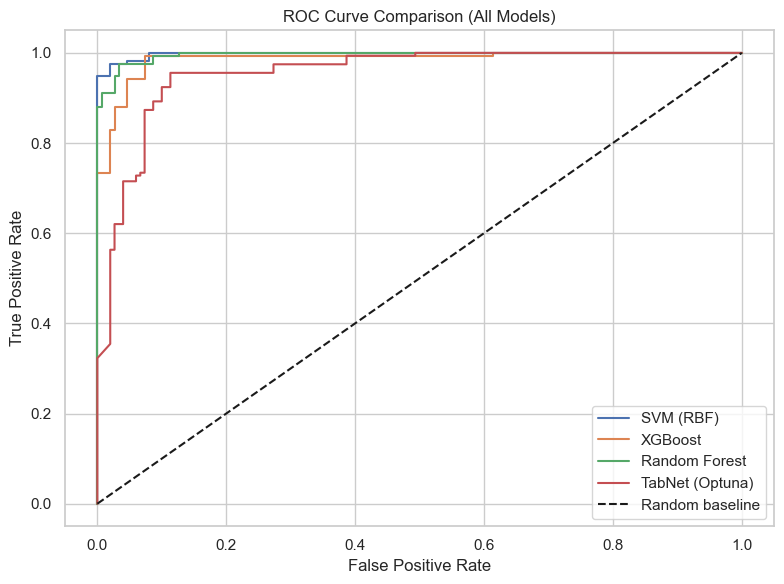


Đã lưu:
 - scaler.pkl
 - selected_features.pkl
 - svm_model.pkl
 - rf_model.pkl
 - tabnet_optuna.zip
 - feature_selection_meta.json
Models dir: E:\DataMinig\backend\app\models


In [10]:
results_df = pd.DataFrame(results).sort_values(by="auc", ascending=False)
print("\n=== RESULTS (sorted by AUC) ===")
print(results_df)

plt.figure(figsize=(8, 6))
for name, (fpr, tpr, _) in roc_curves.items():
    plt.plot(fpr, tpr, label=name)

plt.plot([0, 1], [0, 1], "k--", label="Random baseline")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison (All Models)")
plt.legend()
plt.tight_layout()
plt.show()


joblib.dump(scaler, MODELS_DIR / "scaler.pkl")
joblib.dump(selected_features, MODELS_DIR / "selected_features.pkl")

# XGBoost
xgb_model.save_model(str(MODELS_DIR / "xgb_model.json"))


# SVM / RF
joblib.dump(svm_model, MODELS_DIR / "svm_model.pkl")
joblib.dump(rf_model, MODELS_DIR / "rf_model.pkl")

# Save meta
meta = {
    "selected_features": selected_features,
    "gini_importances": gini_importances.to_dict(),
    "rf_cv_best": {
        "k": int(rf_best["k"]),
        "mean_auc": float(rf_best["mean_auc"]),
        "std_auc": float(rf_best["std_auc"]),
        "mean_fit_time_sec": float(rf_best["mean_fit_time_sec"]),
    },
    "rf_cv_chosen": {
        "k": int(rf_chosen["k"]),
        "mean_auc": float(rf_chosen["mean_auc"]),
        "std_auc": float(rf_chosen["std_auc"]),
        "mean_fit_time_sec": float(rf_chosen["mean_fit_time_sec"]),
    },
    "tabnet_optuna_best": {
        "best_cv_auc": float(study.best_value),
        "best_params": study.best_params
    }
}
pd.Series(meta, dtype="object").to_json(MODELS_DIR / "feature_selection_meta.json", force_ascii=False, indent=2)

print("\nĐã lưu:")
print(" - scaler.pkl")
print(" - selected_features.pkl")
print(" - svm_model.pkl")
print(" - rf_model.pkl")
print(" - tabnet_optuna.zip")
print(" - feature_selection_meta.json")
print("Models dir:", MODELS_DIR.resolve())

